# Yellow taxi fare regression with PyTorch

End-to-end: **cleaning**, **imputation**, **feature selection**, optional **PCA**, then **comparisons** of shallow vs deep vs deep+dropout networks and of **activation functions** (ReLU, Tanh, Leaky ReLU, Sigmoid). The best model (by validation loss) is used for **example predictions** on the test set.


**Data:** yellow_tripdata_2021-01.parquet
Paths: "dataset_nyc_parquet/yellow_tripdata_2021-01.parquet".

**Target:** `fare_amount`. Features avoid leakage from tips, tolls, taxes, and totals.


In [20]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1. Load data

Adjust `MAX_ROWS` for speed vs realism.


In [ ]:
from pathlib import Path
import pandas as pd

# Path to dataset
DATA_PATH = Path("../dataset_nyc_parquet/yellow_tripdata_2021-01.parquet")

# Load dataset
if not DATA_PATH.exists():
    raise FileNotFoundError("Combined dataset not found. Make sure yellow_tripdata_2021-01.parquet exists.")
df = pd.read_parquet(DATA_PATH)

#reduce size for faster training
MAX_ROWS = 250_000
RANDOM_SEED = 42

if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (250000, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2021-01-08 16:13:50,2021-01-08 16:21:50,3.0,1.54,1.0,N,170,237,2,7.50,1.00,0.5,0.00,0.0,0.3,11.80,2.5,NaN
1,2,2021-01-12 18:09:12,2021-01-12 18:18:20,1.0,1.60,1.0,N,100,142,1,8.00,1.00,0.5,2.46,0.0,0.3,14.76,2.5,NaN
2,2,2021-01-25 07:35:00,2021-01-25 08:04:00,NaN,9.06,NaN,NaN,166,231,0,37.98,2.75,0.5,0.00,0.0,0.3,41.53,NaN,NaN
3,1,2021-01-23 19:54:02,2021-01-23 19:56:30,1.0,0.50,1.0,N,262,141,1,4.00,3.00,0.5,2.30,0.0,0.3,10.10,2.5,NaN
4,1,2021-01-14 13:33:43,2021-01-14 13:55:34,1.0,0.00,1.0,N,55,178,1,19.20,0.00,0.5,0.00,0.0,0.3,20.00,0.0,NaN


## 2. Cleaning

Drop bad datetimes and impossible trips. **Imputation** for remaining missing values happens in sklearn pipelines below.


In [22]:
pickup_col = "tpep_pickup_datetime" if "tpep_pickup_datetime" in df.columns else "pickup_datetime"
dropoff_col = "tpep_dropoff_datetime" if "tpep_dropoff_datetime" in df.columns else "dropoff_datetime"

df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")

df = df.dropna(subset=[pickup_col, dropoff_col, "fare_amount", "trip_distance"])
df = df[df[dropoff_col] > df[pickup_col]]

df["trip_duration_sec"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds()

df = df[
    (df["fare_amount"] > 0)
    & (df["fare_amount"] < 500)
    & (df["trip_distance"] > 0)
    & (df["trip_distance"] < 100)
    & (df["trip_duration_sec"] > 60)
    & (df["trip_duration_sec"] < 4 * 3600)
].copy()

if "passenger_count" in df.columns:
    df["passenger_count"] = df["passenger_count"].clip(lower=1, upper=6)

print("Rows after cleaning:", len(df))
df[["fare_amount", "trip_distance", "trip_duration_sec"]].describe()


Rows after cleaning: 242626


,fare_amount,trip_distance,trip_duration_sec
count,242626.000000,242626.000000,242626.000000
mean,12.003354,2.925385,703.193879
std,10.578218,3.685197,561.653415
min,0.010000,0.010000,61.000000
25%,6.000000,1.020000,342.000000
50%,8.500000,1.700000,548.000000
75%,13.000000,3.040000,875.000000
max,300.000000,90.000000,14370.000000


## 3. Features (no fare-line leakage)

Exclude columns that encode the bill breakdown. Engineer time features.


In [23]:
LEAKAGE_COLS = {
    "tip_amount", "tolls_amount", "extra", "mta_tax", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "airport_fee", "cbd_congestion_fee",
    "Airport_fee",
}

df["pickup_hour"] = df[pickup_col].dt.hour
df["pickup_dow"] = df[pickup_col].dt.dayofweek
df["pickup_month"] = df[pickup_col].dt.month

numeric_features = [
    "trip_distance", "trip_duration_sec", "pickup_hour", "pickup_dow", "pickup_month",
]
if "passenger_count" in df.columns:
    numeric_features.insert(1, "passenger_count")

cat_features = []
for c in ("RatecodeID", "payment_type", "VendorID"):
    if c in df.columns:
        cat_features.append(c)

for c in cat_features:
    df[c] = df[c].astype(str)

y = df["fare_amount"].astype(np.float32).values
X = df[numeric_features + cat_features].copy()

for c in LEAKAGE_COLS:
    if c in X.columns:
        X = X.drop(columns=[c])

X.head()


,trip_distance,passenger_count,trip_duration_sec,pickup_hour,pickup_dow,pickup_month,RatecodeID,payment_type,VendorID
0,1.54,3.0,480.0,16,4,1,1.0,2,2
1,1.60,1.0,548.0,18,1,1,1.0,1,2
2,9.06,NaN,1740.0,7,0,1,NaN,0,2
3,0.50,1.0,148.0,19,5,1,1.0,1,1
5,2.20,1.0,713.0,9,2,1,1.0,2,1


## 4. Train / validation / test split

Random split for the demo; time-based split is better for deployment.


In [24]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85, random_state=RANDOM_SEED
)
print("train", len(X_train), "val", len(X_val), "test", len(X_test))


train 169838 val 36394 test 36394


## 5. Preprocessing: impute → scale / one-hot → `SelectKBest` → optional PCA




In [25]:
USE_PCA = True
K_BEST = 40
PCA_VAR = 0.95

num_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=30),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop",
)

X_tr = preprocess.fit_transform(X_train)
X_va = preprocess.transform(X_val)
X_te = preprocess.transform(X_test)

selector = SelectKBest(score_func=f_regression, k=min(K_BEST, X_tr.shape[1]))
X_tr_s = selector.fit_transform(X_tr, y_train)
X_va_s = selector.transform(X_va)
X_te_s = selector.transform(X_te)
print("After SelectKBest:", X_tr_s.shape[1])

if USE_PCA:
    pca = PCA(n_components=PCA_VAR, svd_solver="full")
    X_tr_s = pca.fit_transform(X_tr_s)
    X_va_s = pca.transform(X_va_s)
    X_te_s = pca.transform(X_te_s)
    print("PCA dims:", X_tr_s.shape[1], "variance:", float(pca.explained_variance_ratio_.sum()))

scaler_y = StandardScaler()
y_train_z = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel().astype(np.float32)
y_val_z = scaler_y.transform(y_val.reshape(-1, 1)).ravel().astype(np.float32)
y_test_z = scaler_y.transform(y_test.reshape(-1, 1)).ravel().astype(np.float32)

IN_DIM = X_tr_s.shape[1]


After SelectKBest: 20
PCA dims: 7 variance: 0.9558866251280417


## 6. DataLoaders


In [26]:
BATCH_SIZE = 2048


def make_loader(x: np.ndarray, y_arr: np.ndarray, shuffle: bool) -> DataLoader:
    ds = TensorDataset(
        torch.tensor(x, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)


train_loader = make_loader(X_tr_s, y_train_z, shuffle=True)
val_loader = make_loader(X_va_s, y_val_z, shuffle=False)
test_loader = make_loader(X_te_s, y_test_z, shuffle=False)
IN_DIM


7

## 7. Activation shapes (illustration)

How ReLU, Tanh, Leaky ReLU, and Sigmoid behave on a 1D input range.


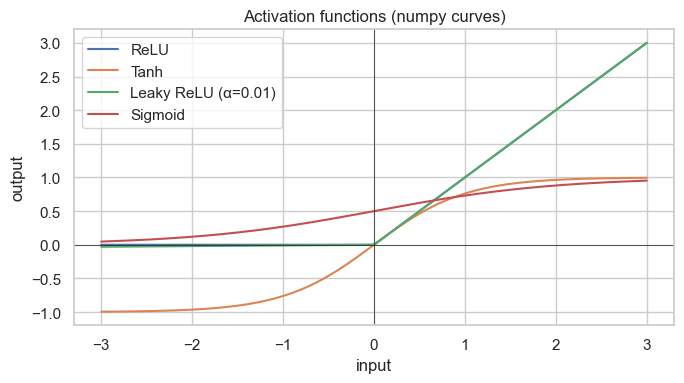

In [27]:
x = np.linspace(-3, 3, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.maximum(0, x), label="ReLU")
ax.plot(x, np.tanh(x), label="Tanh")
ax.plot(x, np.where(x > 0, x, 0.01 * x), label="Leaky ReLU (α=0.01)")
ax.plot(x, 1 / (1 + np.exp(-x)), label="Sigmoid")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("input")
ax.set_ylabel("output")
ax.legend()
ax.set_title("Activation functions (numpy curves)")
plt.tight_layout()
plt.show()


## 8. Model factory, training loop, metrics

- **Early stopping** on validation MSE (scaled target).  
- **ReduceLROnPlateau** for learning-rate decay.  
- **AdamW** with weight decay.


In [28]:
def make_activation(name: str) -> nn.Module:
    n = name.lower()
    if n == "relu":
        return nn.ReLU(inplace=True)
    if n == "tanh":
        return nn.Tanh()
    if n == "leaky_relu":
        return nn.LeakyReLU(0.01, inplace=True)
    if n == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)


class FareMLP(nn.Module):
    def __init__(
        self,
        in_features: int,
        hidden: tuple[int, ...],
        act_name: str = "relu",
        dropout_p: float = 0.0,
    ):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_features
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(make_activation(act_name))
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    train: bool,
) -> float:
    if train:
        model.train()
    else:
        model.eval()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        if train:
            assert optimizer is not None
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            pred = model(xb)
            loss = criterion(pred, yb)
        if train:
            loss.backward()
            optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def metrics_dollars(model: nn.Module, loader: DataLoader) -> tuple[float, float, float]:
    model.eval()
    preds, actuals = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pz = model(xb).cpu().numpy()
        preds.append(pz)
        actuals.append(yb.numpy())
    pz = np.vstack(preds).ravel()
    az = np.vstack(actuals).ravel()
    pred = scaler_y.inverse_transform(pz.reshape(-1, 1)).ravel()
    act = scaler_y.inverse_transform(az.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(act, pred)
    rmse = root_mean_squared_error(act, pred)
    r2 = r2_score(act, pred)
    return mae, rmse, r2


def train_one_run(
    name: str,
    hidden: tuple[int, ...],
    act_name: str,
    dropout_p: float,
    seed_offset: int = 0,
    epochs: int = 100,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 12,
    verbose: bool = False,
) -> dict:
    torch.manual_seed(RANDOM_SEED + seed_offset)
    model = FareMLP(IN_DIM, hidden, act_name=act_name, dropout_p=dropout_p).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4, min_lr=1e-6
    )

    history = {"train_mse": [], "val_mse": [], "lr": []}
    best_val = float("inf")
    best_state: dict | None = None
    stale = 0

    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer, train=True)
        va = run_epoch(model, val_loader, criterion, None, train=False)
        scheduler.step(va)
        lr_now = optimizer.param_groups[0]["lr"]
        history["train_mse"].append(tr)
        history["val_mse"].append(va)
        history["lr"].append(lr_now)

        if va < best_val - 1e-8:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"[{name}] epoch {epoch:03d} train_mse={tr:.5f} val_mse={va:.5f} lr={lr_now:.2e}")

        if stale >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    mae, rmse, r2 = metrics_dollars(model, test_loader)
    return {
        "name": name,
        "hidden": hidden,
        "act_name": act_name,
        "dropout_p": dropout_p,
        "best_val_mse": best_val,
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
        "history": history,
        "model": model,
    }


## 9. Comparison A — architecture (fixed **ReLU**)

| Variant | Hidden layers | Dropout |
|---------|----------------|---------|
| Shallow | (64, 32) | 0 |
| Deep | (128, 96, 64, 32) | 0 |
| Deep + dropout | (128, 96, 64, 32) | 0.25 |

Lower **test MAE** is better (same test set for all; for rigorous model selection use validation only).


[shallow_relu] epoch 001 train_mse=0.17395 val_mse=0.12060 lr=1.00e-03
[shallow_relu] epoch 010 train_mse=0.08025 val_mse=0.10354 lr=1.00e-03
[shallow_relu] epoch 020 train_mse=0.07341 val_mse=0.10128 lr=5.00e-04
[shallow_relu] epoch 030 train_mse=0.06992 val_mse=0.10227 lr=2.50e-04
[shallow_relu] epoch 040 train_mse=0.06971 val_mse=0.09187 lr=2.50e-04
[shallow_relu] epoch 050 train_mse=0.06862 val_mse=0.11009 lr=2.50e-04
[shallow_relu] epoch 060 train_mse=0.06824 val_mse=0.09045 lr=6.25e-05
[deep_relu] epoch 001 train_mse=0.15409 val_mse=0.11033 lr=1.00e-03
[deep_relu] epoch 010 train_mse=0.07350 val_mse=0.09374 lr=1.00e-03
[deep_relu] epoch 020 train_mse=0.07034 val_mse=0.09764 lr=5.00e-04
[deep_relu] epoch 030 train_mse=0.06506 val_mse=0.16859 lr=2.50e-04
[deep_relu] epoch 040 train_mse=0.06190 val_mse=0.08188 lr=1.25e-04
[deep_relu] epoch 050 train_mse=0.06015 val_mse=0.09263 lr=6.25e-05
[deep_relu_dropout] epoch 001 train_mse=0.32525 val_mse=0.14914 lr=1.00e-03
[deep_relu_dropout]

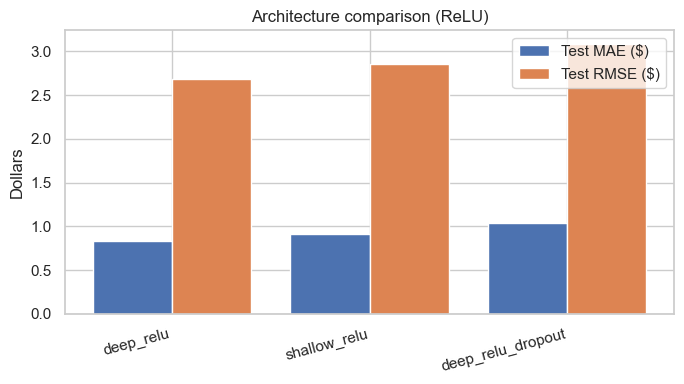


Lowest test MAE in this run (architecture sweep): deep_relu


In [29]:
arch_results = []
arch_results.append(
    train_one_run("shallow_relu", (64, 32), "relu", 0.0, seed_offset=1, verbose=True)
)
arch_results.append(
    train_one_run("deep_relu", (128, 96, 64, 32), "relu", 0.0, seed_offset=2, verbose=True)
)
arch_results.append(
    train_one_run("deep_relu_dropout", (128, 96, 64, 32), "relu", 0.25, seed_offset=3, verbose=True)
)

arch_df = pd.DataFrame(
    [
        {
            "model": r["name"],
            "best_val_mse_scaled": r["best_val_mse"],
            "test_mae_$": r["test_mae"],
            "test_rmse_$": r["test_rmse"],
            "test_R2": r["test_r2"],
        }
        for r in arch_results
    ]
)
arch_df = arch_df.sort_values("test_mae_$").reset_index(drop=True)
print(arch_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(arch_df))
ax.bar(x - 0.2, arch_df["test_mae_$"], 0.4, label="Test MAE ($)")
ax.bar(x + 0.2, arch_df["test_rmse_$"], 0.4, label="Test RMSE ($)")
ax.set_xticks(x)
ax.set_xticklabels(arch_df["model"], rotation=15, ha="right")
ax.set_ylabel("Dollars")
ax.legend()
ax.set_title("Architecture comparison (ReLU)")
plt.tight_layout()
plt.show()

best_arch_name = arch_df.loc[arch_df["test_mae_$"].idxmin(), "model"]
print(f"\nLowest test MAE in this run (architecture sweep): {best_arch_name}")


## 10. Comparison B — activations (fixed **deep + dropout**)

Same hidden sizes `(128, 96, 64, 32)` and `dropout=0.25`; only the hidden activation changes. Output layer stays **linear** (regression).


[deep_do_relu] epoch 001 train_mse=0.22488 val_mse=0.13786 lr=1.00e-03
[deep_do_relu] epoch 010 train_mse=0.12282 val_mse=0.12952 lr=1.00e-03
[deep_do_relu] epoch 020 train_mse=0.11242 val_mse=0.10624 lr=5.00e-04
[deep_do_relu] epoch 030 train_mse=0.11149 val_mse=0.11951 lr=2.50e-04
[deep_do_relu] epoch 040 train_mse=0.11049 val_mse=0.10750 lr=1.25e-04
[deep_do_relu] epoch 050 train_mse=0.10732 val_mse=0.11152 lr=6.25e-05
[deep_do_tanh] epoch 001 train_mse=0.38658 val_mse=0.22386 lr=1.00e-03
[deep_do_tanh] epoch 010 train_mse=0.20761 val_mse=0.15887 lr=1.00e-03
[deep_do_tanh] epoch 020 train_mse=0.17334 val_mse=0.14613 lr=1.00e-03
[deep_do_tanh] epoch 030 train_mse=0.15627 val_mse=0.13256 lr=1.00e-03
[deep_do_tanh] epoch 040 train_mse=0.14206 val_mse=0.12380 lr=1.00e-03
[deep_do_tanh] epoch 050 train_mse=0.12904 val_mse=0.11790 lr=1.00e-03
[deep_do_tanh] epoch 060 train_mse=0.12302 val_mse=0.10798 lr=1.00e-03
[deep_do_tanh] epoch 070 train_mse=0.11844 val_mse=0.10864 lr=5.00e-04
[deep_

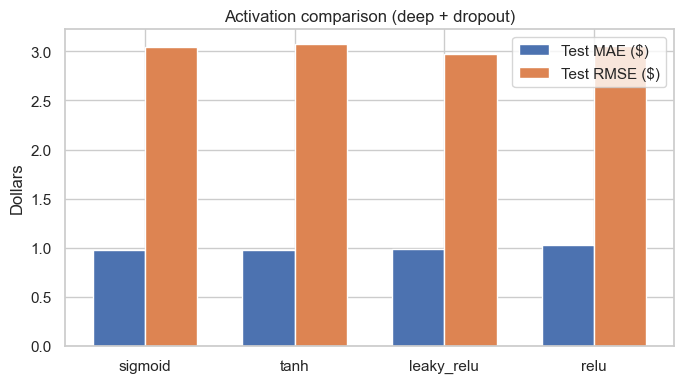


Champion (lowest val MSE among activations): deep_do_leaky_relu — act=leaky_relu, test MAE=$0.99


In [17]:
act_names = ["relu", "tanh", "leaky_relu", "sigmoid"]
act_results = []
for i, act in enumerate(act_names):
    act_results.append(
        train_one_run(
            f"deep_do_{act}",
            (128, 96, 64, 32),
            act,
            0.25,
            seed_offset=10 + i,
            verbose=True,
        )
    )

act_df = pd.DataFrame(
    [
        {
            "activation": r["act_name"],
            "best_val_mse_scaled": r["best_val_mse"],
            "test_mae_$": r["test_mae"],
            "test_rmse_$": r["test_rmse"],
            "test_R2": r["test_r2"],
        }
        for r in act_results
    ]
)
act_df = act_df.sort_values("test_mae_$").reset_index(drop=True)
print(act_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(act_df))
w = 0.35
ax.bar(x - w / 2, act_df["test_mae_$"], w, label="Test MAE ($)")
ax.bar(x + w / 2, act_df["test_rmse_$"], w, label="Test RMSE ($)")
ax.set_xticks(x)
ax.set_xticklabels(act_df["activation"])
ax.set_ylabel("Dollars")
ax.legend()
ax.set_title("Activation comparison (deep + dropout)")
plt.tight_layout()
plt.show()

# Champion = best validation MSE (matches early-stopping objective)
best_act_row = min(act_results, key=lambda r: r["best_val_mse"])
champion = best_act_row
print(
    f"\nChampion (lowest val MSE among activations): {champion['name']} "
    f"— act={champion['act_name']}, test MAE=${champion['test_mae']:.2f}"
)


## 11. Example predictions (champion on **test**)

Table of sample rows: actual fare, prediction, error. The champion model is the activation sweep winner (by validation MSE).


In [18]:
champ = champion["model"]
champ.eval()

# Build a small batch from test features + original rows for readable columns
n_show = 15
# Align test indices: use first n_show rows from X_test for feature context
idx = np.arange(n_show)
X_samp = X_test.iloc[idx].reset_index(drop=True)
y_samp = y_test[idx]

with torch.no_grad():
    xb = torch.tensor(X_te_s[idx], dtype=torch.float32, device=DEVICE)
    pred_z = champ(xb).cpu().numpy().ravel()
pred = scaler_y.inverse_transform(pred_z.reshape(-1, 1)).ravel()

pred_tbl = pd.DataFrame(
    {
        "trip_mi": X_samp["trip_distance"].values,
        "dur_min": (X_samp["trip_duration_sec"].values / 60).round(1),
        "hour": X_samp["pickup_hour"].values,
        "actual_fare": y_samp,
        "predicted_fare": np.round(pred, 2),
        "error_$": np.round(pred - y_samp, 2),
    }
)
pred_tbl


,trip_mi,dur_min,hour,actual_fare,predicted_fare,error_$
0,2.62,10.2,20,13.740000,15.450000,1.71
1,9.64,22.0,9,29.139999,31.809999,2.67
2,2.97,17.1,7,13.500000,14.430000,0.93
3,3.29,15.0,10,13.500000,13.210000,-0.29
4,3.00,11.3,11,11.500000,11.270000,-0.23
5,0.90,5.2,10,6.000000,5.660000,-0.34
6,0.87,4.8,20,5.500000,5.550000,0.05
7,0.08,1.0,10,2.500000,3.830000,1.33
8,0.72,11.4,12,8.000000,8.180000,0.18
9,0.80,4.7,14,5.500000,5.620000,0.12


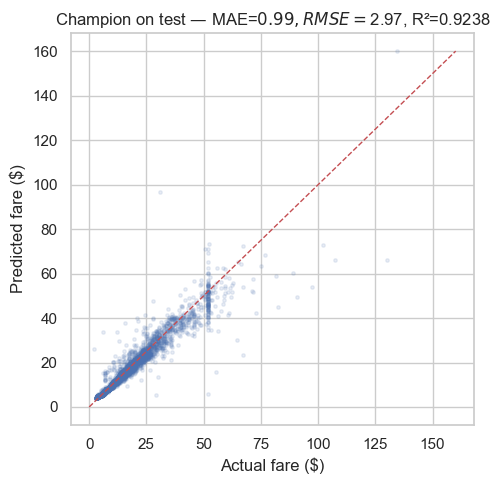

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
# Full test scatter (champion)
mae, rmse, r2 = metrics_dollars(champ, test_loader)
sample = min(8000, len(y_test))
rng = np.random.default_rng(RANDOM_SEED)
pick = rng.choice(len(y_test), size=sample, replace=False)
with torch.no_grad():
    xb = torch.tensor(X_te_s[pick], dtype=torch.float32, device=DEVICE)
    pz = champ(xb).cpu().numpy().ravel()
pred_f = scaler_y.inverse_transform(pz.reshape(-1, 1)).ravel()
act_f = y_test[pick]
ax.scatter(act_f, pred_f, alpha=0.12, s=6)
mx = max(act_f.max(), pred_f.max())
ax.plot([0, mx], [0, mx], "r--", lw=1)
ax.set_xlabel("Actual fare ($)")
ax.set_ylabel("Predicted fare ($)")
ax.set_title(f"Champion on test — MAE=${mae:.2f}, RMSE=${rmse:.2f}, R²={r2:.4f}")
plt.tight_layout()
plt.show()


## 12. Summary

- **Architecture:** Compare shallow vs deep vs deep+dropout with ReLU; deeper nets often benefit from **dropout** on tabular data when they overfit.  
- **Activations:** ReLU / Leaky ReLU often train faster than **sigmoid** in deeper nets; your **test** ranking may differ slightly each run.  
- **Champion selection** used **validation MSE** (scaled) to align with training; metrics on **test** are reported for all models.

